In [40]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("Libraries loaded!")

Libraries loaded!


In [41]:
# Load the merged dataset from previous one
df = pd.read_csv("../data/processed/diabetic_with_sdoh.csv")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"First 5 rows:")
df.head(5)

Rows: 101,766
Columns: 48
First 5 rows:


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,metformin-pioglitazone,change,diabetesMed,readmitted_30,BPHIGH,CHECKUP,CHOLSCREEN,DEPRESSION,DIABETES,OBESITY
0,2,0,5,6,25,1,1,37,41,0,...,0,1,0,0,39.91,80.29,85.29,22.56,14.97,39.06
1,2,0,15,1,1,7,3,71,59,0,...,0,0,1,0,33.70,74.93,83.03,17.68,11.04,39.57
2,0,0,25,1,1,7,2,71,11,5,...,0,1,1,0,34.65,77.01,85.42,22.72,11.38,38.56
3,2,1,35,1,1,7,2,71,44,1,...,0,0,1,0,30.13,71.69,80.58,26.48,9.93,31.68
4,2,1,45,1,1,7,1,71,51,0,...,0,0,1,0,29.40,76.40,89.75,21.30,8.15,24.90


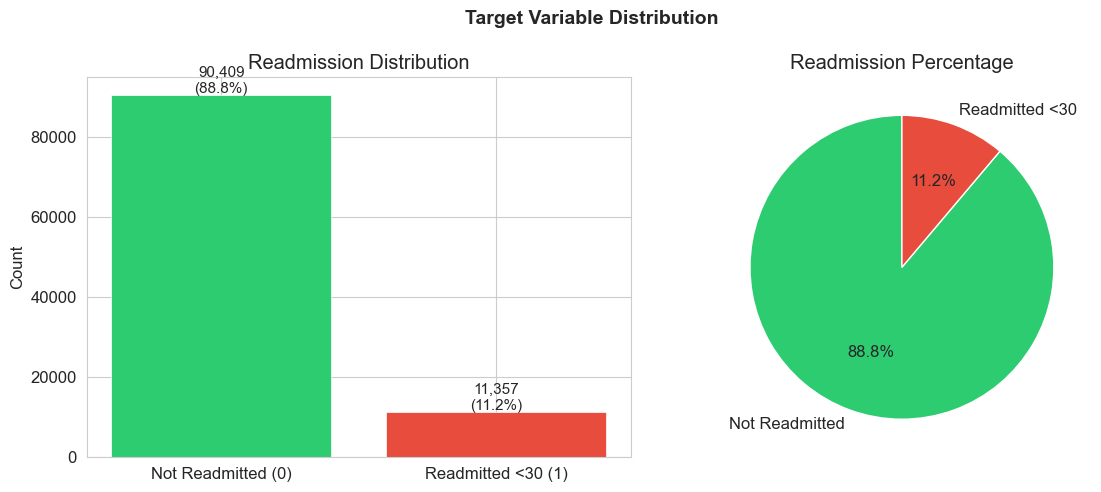

Plot saved!


In [42]:
## --- target variable distribution --- 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['readmitted_30'].value_counts()
axes[0].bar(['Not Readmitted (0)', 'Readmitted <30 (1)'], 
            counts.values, 
            color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=0.5)
axes[0].set_title('Readmission Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts.values, 
            labels=['Not Readmitted', 'Readmitted <30'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Readmission Percentage')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../dashboard/target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

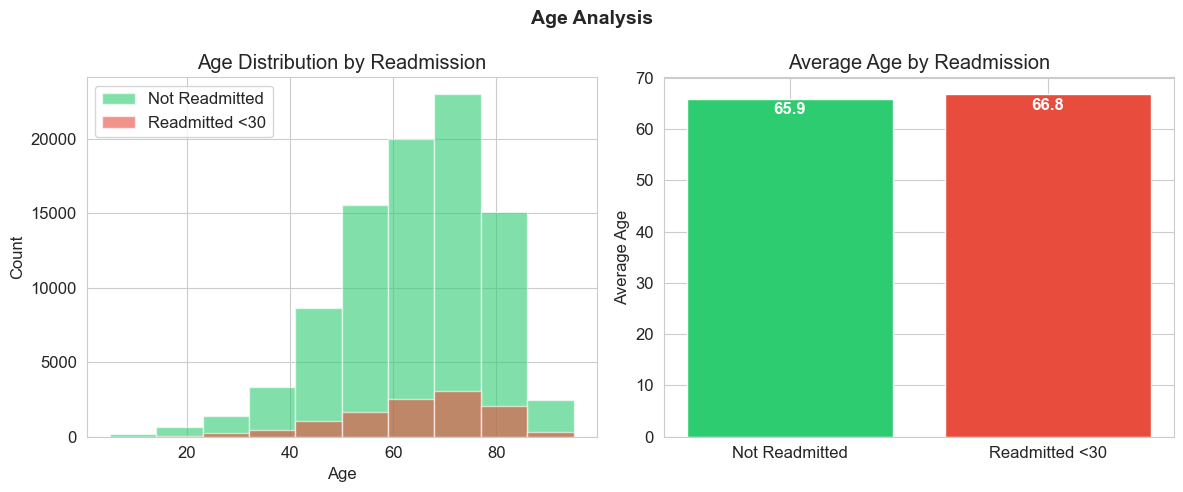

Plot saved!


In [43]:
## --- Age Analysis ---

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age distribution
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['readmitted_30'] == label]['age']
    axes[0].hist(subset, bins=10, alpha=0.6, 
                color=color, edgecolor='white',
                label='Not Readmitted' if label==0 else 'Readmitted <30')
axes[0].set_title('Age Distribution by Readmission')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Average age by readmission
avg_age = df.groupby('readmitted_30')['age'].mean()
axes[1].bar(['Not Readmitted', 'Readmitted <30'], 
            avg_age.values,
            color=['#2ecc71', '#e74c3c'],
            edgecolor='white')
axes[1].set_title('Average Age by Readmission')
axes[1].set_ylabel('Average Age')
for i, v in enumerate(avg_age.values):
    axes[1].text(i, v - 3, f'{v:.1f}', ha='center', 
                color='white', fontweight='bold')

plt.suptitle('Age Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../dashboard/age_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

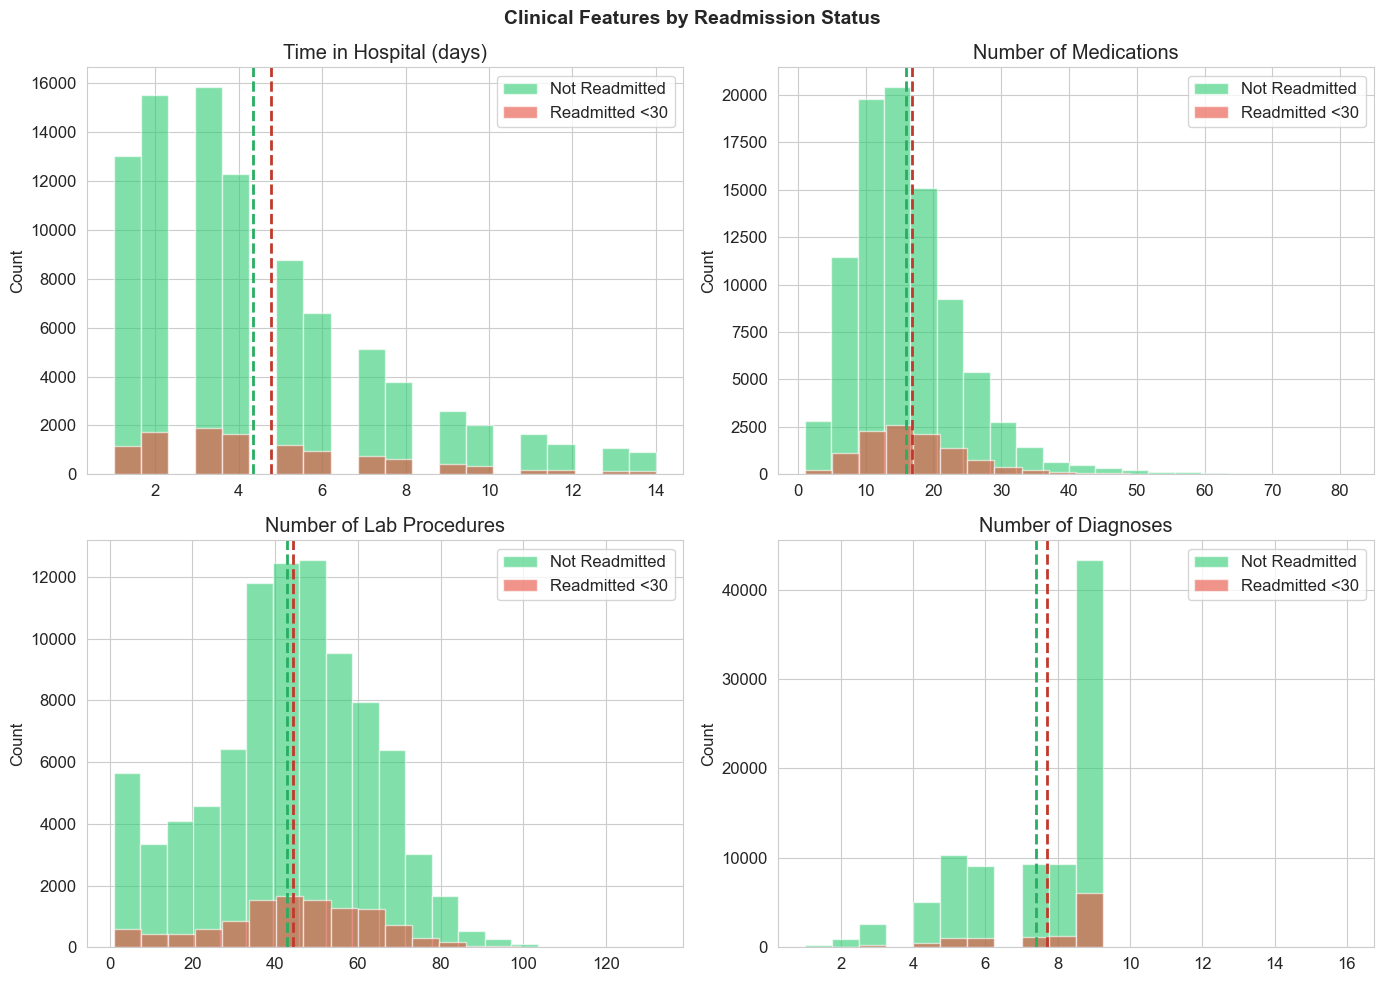

Plot saved!


In [44]:
## --- Clinical features analysis ---
# (Hospital stay & procedures analysis)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

clinical_features = [
    ('time_in_hospital', 'Time in Hospital (days)'),
    ('num_medications', 'Number of Medications'),
    ('num_lab_procedures', 'Number of Lab Procedures'),
    ('number_diagnoses', 'Number of Diagnoses')
]

for ax, (col, title) in zip(axes.flatten(), clinical_features):
    readmitted = df[df['readmitted_30']==1][col]
    not_readmitted = df[df['readmitted_30']==0][col]
    
    ax.hist(not_readmitted, bins=20, alpha=0.6, 
            color='#2ecc71', label='Not Readmitted', edgecolor='white')
    ax.hist(readmitted, bins=20, alpha=0.6, 
            color='#e74c3c', label='Readmitted <30', edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.legend()
    
    # Add mean lines
    ax.axvline(readmitted.mean(), color='#c0392b', 
               linestyle='--', linewidth=2,
               label=f'Readmitted mean: {readmitted.mean():.1f}')
    ax.axvline(not_readmitted.mean(), color='#27ae60', 
               linestyle='--', linewidth=2,
               label=f'Not readmitted mean: {not_readmitted.mean():.1f}')

plt.suptitle('Clinical Features by Readmission Status', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../dashboard/clinical_features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

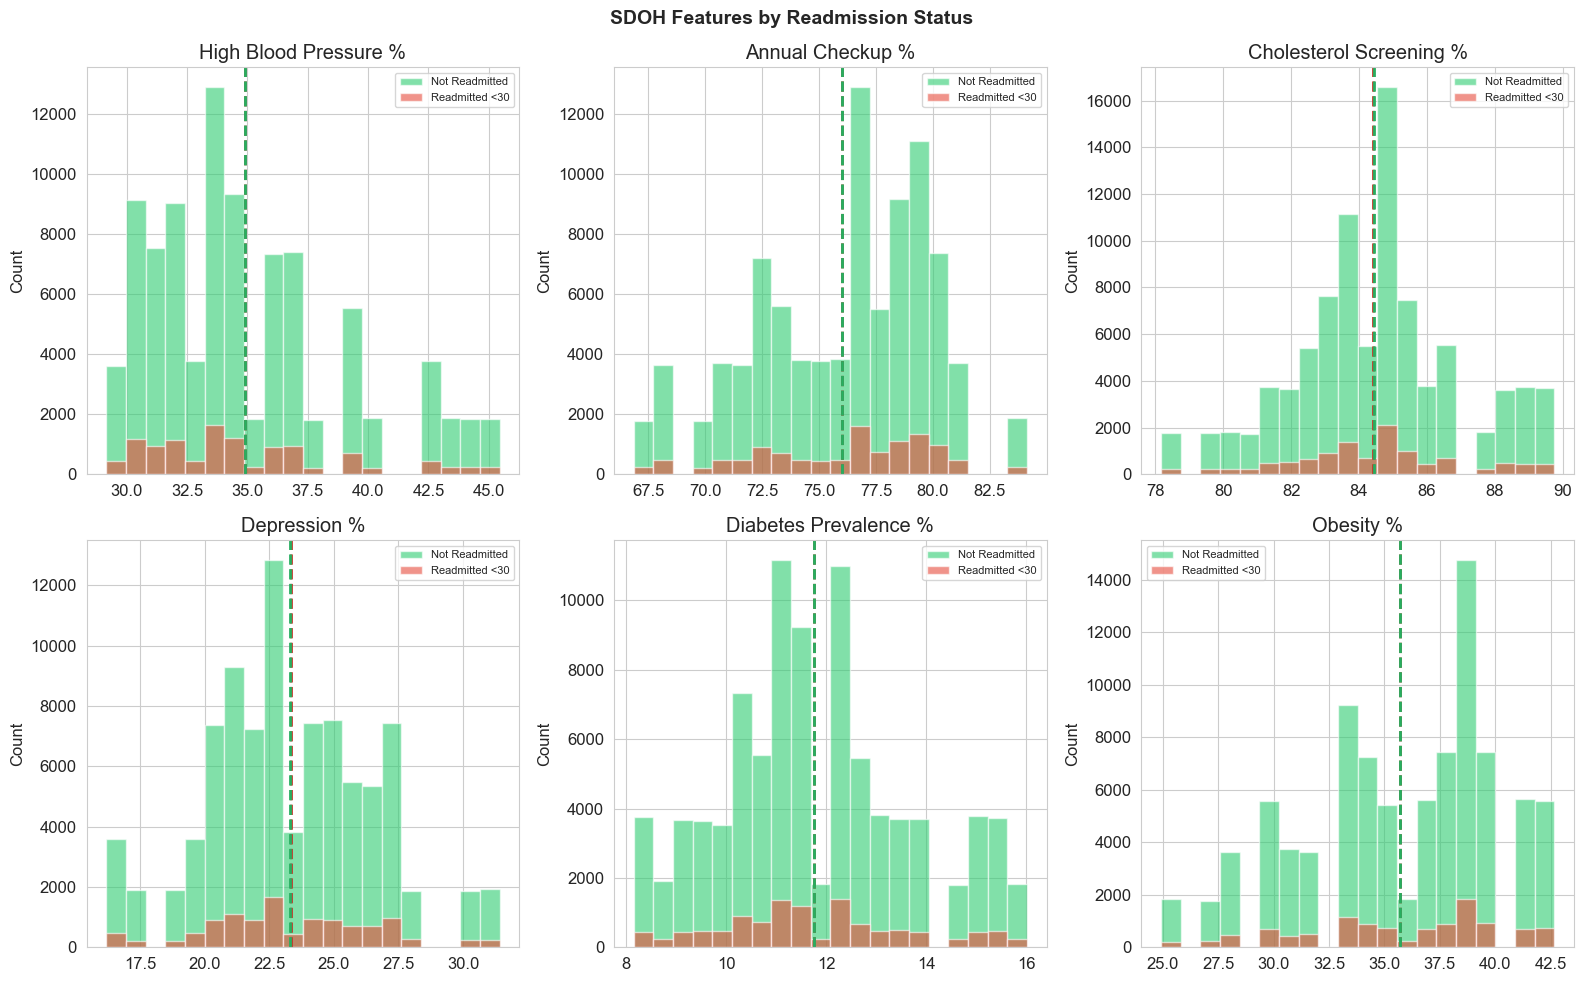

Plot saved!


In [45]:
## -- SDOH features analysis ---

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sdoh_features = [
    ('BPHIGH', 'High Blood Pressure %'),
    ('CHECKUP', 'Annual Checkup %'),
    ('CHOLSCREEN', 'Cholesterol Screening %'),
    ('DEPRESSION', 'Depression %'),
    ('DIABETES', 'Diabetes Prevalence %'),
    ('OBESITY', 'Obesity %')
]

for ax, (col, title) in zip(axes.flatten(), sdoh_features):
    readmitted = df[df['readmitted_30']==1][col]
    not_readmitted = df[df['readmitted_30']==0][col]
    
    ax.hist(not_readmitted, bins=20, alpha=0.6,
            color='#2ecc71', label='Not Readmitted', edgecolor='white')
    ax.hist(readmitted, bins=20, alpha=0.6,
            color='#e74c3c', label='Readmitted <30', edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    
    # Add mean lines
    ax.axvline(readmitted.mean(), color='#c0392b',
               linestyle='--', linewidth=2)
    ax.axvline(not_readmitted.mean(), color='#27ae60',
               linestyle='--', linewidth=2)

plt.suptitle('SDOH Features by Readmission Status',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../dashboard/sdoh_features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

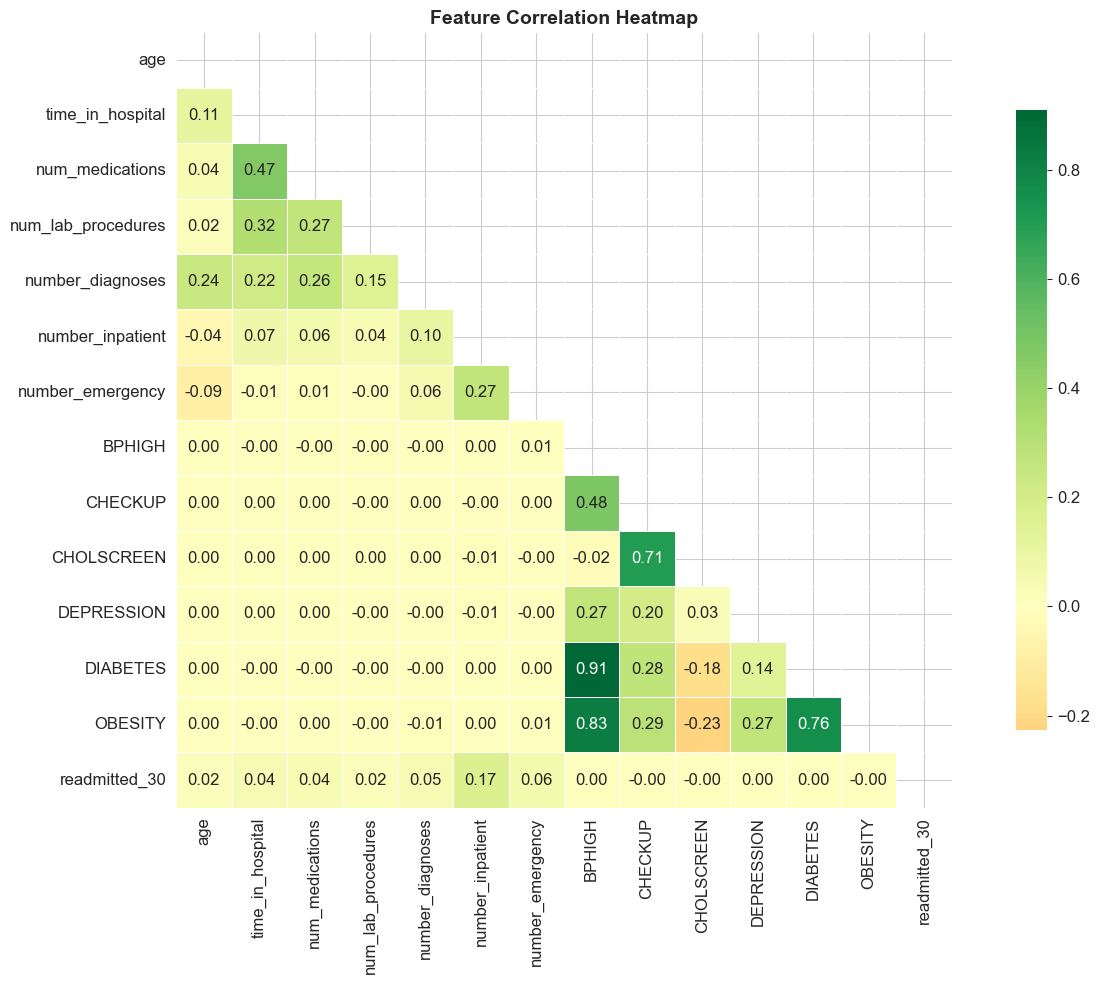

Plot saved!


In [46]:
## --- Correlation heatmap ---

# Correlation heatmap of key features
key_cols = [
    'age', 'time_in_hospital', 'num_medications',
    'num_lab_procedures', 'number_diagnoses',
    'number_inpatient', 'number_emergency',
    'BPHIGH', 'CHECKUP', 'CHOLSCREEN',
    'DEPRESSION', 'DIABETES', 'OBESITY',
    'readmitted_30'
]

corr_matrix = df[key_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../dashboard/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

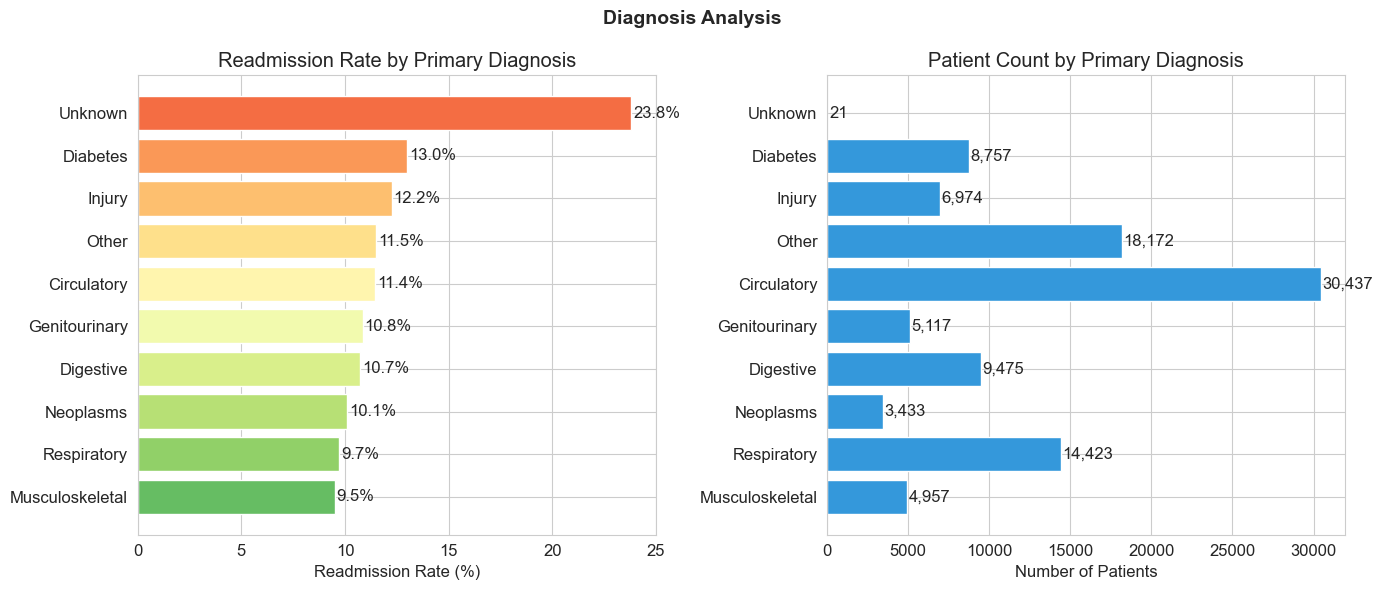

Plot saved!


In [47]:
## --- Diagnosis Analysis ---

# Readmission rate by primary diagnosis category
diag_readmission = df.groupby('diag_1')['readmitted_30'].agg(['mean', 'count']).reset_index()
diag_readmission.columns = ['diag_1', 'readmission_rate', 'count']
diag_readmission['readmission_rate'] = diag_readmission['readmission_rate'] * 100
diag_readmission = diag_readmission.sort_values('readmission_rate', ascending=True)

# Map encoded values back to labels
diag_labels = {
    0: 'Circulatory',
    1: 'Diabetes', 
    2: 'Digestive',
    3: 'Genitourinary',
    4: 'Injury',
    5: 'Musculoskeletal',
    6: 'Neoplasms',
    7: 'Other',
    8: 'Respiratory',
    9: 'Unknown'
}
diag_readmission['diag_label'] = diag_readmission['diag_1'].map(diag_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Readmission rate by diagnosis
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(diag_readmission)))
axes[0].barh(diag_readmission['diag_label'], 
             diag_readmission['readmission_rate'],
             color=colors, edgecolor='white')
axes[0].set_title('Readmission Rate by Primary Diagnosis')
axes[0].set_xlabel('Readmission Rate (%)')
for i, v in enumerate(diag_readmission['readmission_rate']):
    axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center')

# Patient count by diagnosis
axes[1].barh(diag_readmission['diag_label'],
             diag_readmission['count'],
             color='#3498db', edgecolor='white')
axes[1].set_title('Patient Count by Primary Diagnosis')
axes[1].set_xlabel('Number of Patients')
for i, v in enumerate(diag_readmission['count']):
    axes[1].text(v + 100, i, f'{v:,}', va='center')

plt.suptitle('Diagnosis Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../dashboard/diagnosis_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

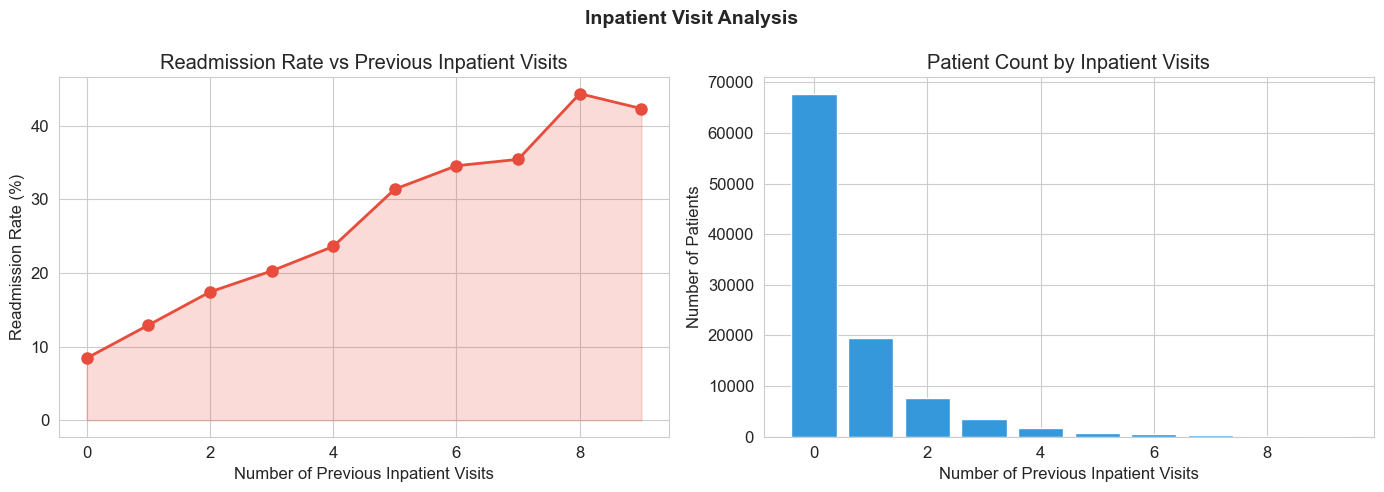

Plot saved!


In [48]:
## --- Inpatient Analysis ---

# Readmission rate by number of previous inpatient visits
inpatient_readmission = df.groupby('number_inpatient')['readmitted_30'].agg(['mean', 'count']).reset_index()
inpatient_readmission.columns = ['number_inpatient', 'readmission_rate', 'count']
inpatient_readmission['readmission_rate'] = inpatient_readmission['readmission_rate'] * 100

# Filter to meaningful range
inpatient_readmission = inpatient_readmission[inpatient_readmission['count'] >= 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Readmission rate trend
axes[0].plot(inpatient_readmission['number_inpatient'],
             inpatient_readmission['readmission_rate'],
             marker='o', color='#e74c3c', linewidth=2, markersize=8)
axes[0].fill_between(inpatient_readmission['number_inpatient'],
                     inpatient_readmission['readmission_rate'],
                     alpha=0.2, color='#e74c3c')
axes[0].set_title('Readmission Rate vs Previous Inpatient Visits')
axes[0].set_xlabel('Number of Previous Inpatient Visits')
axes[0].set_ylabel('Readmission Rate (%)')

# Patient count
axes[1].bar(inpatient_readmission['number_inpatient'],
            inpatient_readmission['count'],
            color='#3498db', edgecolor='white')
axes[1].set_title('Patient Count by Inpatient Visits')
axes[1].set_xlabel('Number of Previous Inpatient Visits')
axes[1].set_ylabel('Number of Patients')

plt.suptitle('Inpatient Visit Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../dashboard/inpatient_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

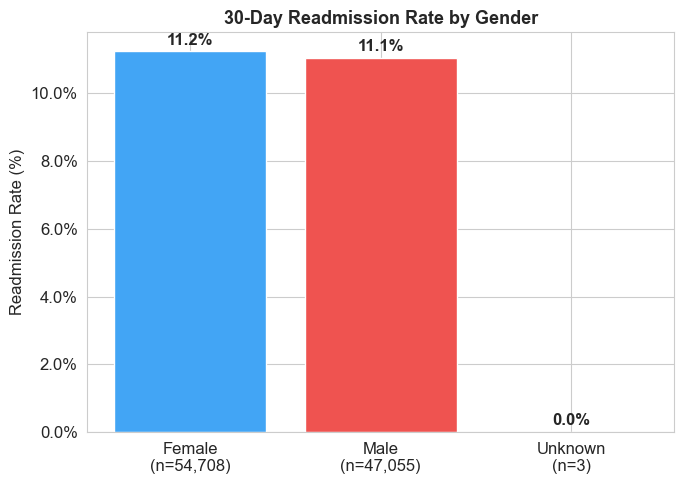

Gender analysis saved!


In [50]:
## --- Gender Analysis ---
import matplotlib.ticker as mticker

# Gender vs Readmission
fig, ax = plt.subplots(figsize=(7, 5))

gender_readmit = df.groupby('gender')['readmitted_30'].mean() * 100
gender_counts = df['gender'].value_counts()

# Map encoded values to labels
gender_labels = {0: 'Female', 1: 'Male', 2: 'Unknown'}

bars = ax.bar(
    [f"{gender_labels.get(g, g)}\n(n={gender_counts.get(g, 0):,})" 
     for g in gender_readmit.index],
    gender_readmit.values,
    color=['#42A5F5', '#EF5350', '#66BB6A'][:len(gender_readmit)]
)

ax.set_title('30-Day Readmission Rate by Gender', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Readmission Rate (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("../dashboard/gender_analysis.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Gender analysis saved!")

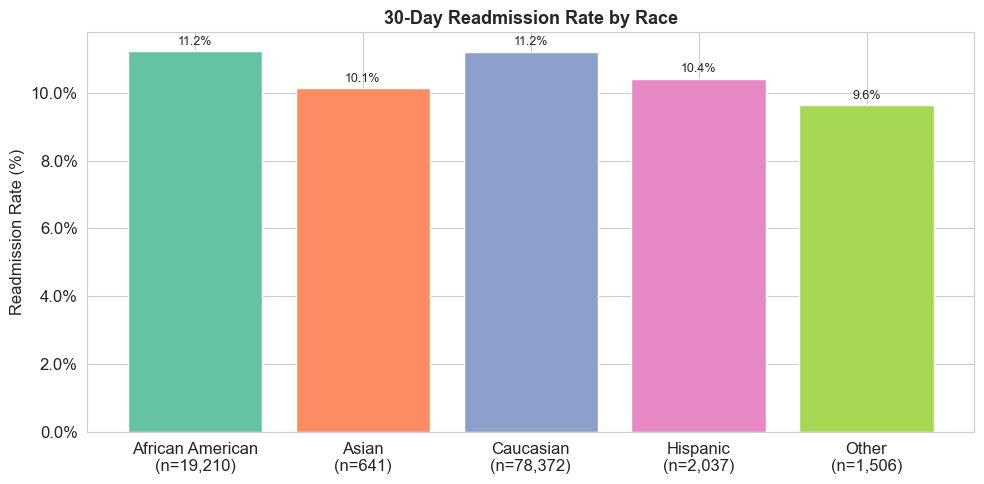

Race analysis saved!


In [51]:
## --- Race Analysis ---
fig, ax = plt.subplots(figsize=(10, 5))

race_readmit = df.groupby('race')['readmitted_30'].mean() * 100
race_counts = df['race'].value_counts()

# Map encoded values to labels
race_labels = {0: 'African American', 1: 'Asian', 
               2: 'Caucasian', 3: 'Hispanic', 
               4: 'Other'}

colors = sns.color_palette('Set2', len(race_readmit))
bars = ax.bar(
    [f"{race_labels.get(r, r)}\n(n={race_counts.get(r, 0):,})" 
     for r in race_readmit.index],
    race_readmit.values,
    color=colors
)

ax.set_title('30-Day Readmission Rate by Race',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Readmission Rate (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("../dashboard/race_analysis.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Race analysis saved!")

In [55]:
## --- Summary statistics table ---
key_features = ['time_in_hospital', 'num_medications',
                'num_lab_procedures', 'num_procedures',
                'number_diagnoses', 'number_inpatient',
                'number_emergency', 'number_outpatient',
                'BPHIGH', 'DEPRESSION', 'OBESITY', 'DIABETES']

summary = df.groupby('readmitted_30')[key_features].agg(
    ['mean', 'median', 'std']).round(2)

print('--- Summary Statistics by Readmission Status ---')
print('0 = Not Readmitted | 1 = Readmitted within 30 days')
print(summary.to_string())

# Save to dashboard folder
summary.to_csv('../dashboard/summary_statistics.csv')
print('Saved to dashboard/summary_statistics.csv')

--- Summary Statistics by Readmission Status ---
0 = Not Readmitted | 1 = Readmitted within 30 days
              time_in_hospital              num_medications              num_lab_procedures               num_procedures              number_diagnoses              number_inpatient              number_emergency              number_outpatient              BPHIGH              DEPRESSION              OBESITY              DIABETES             
                          mean median   std            mean median   std               mean median    std           mean median   std             mean median   std             mean median   std             mean median   std              mean median   std   mean median   std       mean median   std    mean median   std     mean median   std
readmitted_30                                                                                                                                                                                                           

In [61]:
## --- Statistical Significance (t-test) ---
from scipy import stats

print('Statistical Significance (t-test)')
print('Comparing Readmitted vs Not Readmitted patients\n')

group0 = df[df['readmitted_30'] == 0]
group1 = df[df['readmitted_30'] == 1]

for feat in key_features:
    t_stat, p_val = stats.ttest_ind(group0[feat], group1[feat])
    if p_val < 0.001:
        sig = '*** (highly significant)'
    elif p_val < 0.01:
        sig = '** (significant)'
    elif p_val < 0.05:
        sig = '* (significant)'
    else:
        sig = 'ns (not significant)'
    print(f"  {feat:<30} t={t_stat:>7.2f}  p={p_val:.4f}  {sig}")

print("t-test complete!")
print("*** = p < 0.001 | ** = p < 0.01 | * = p < 0.05 | ns = not significant")

Statistical Significance (t-test)
Comparing Readmitted vs Not Readmitted patients

  time_in_hospital               t= -14.11  p=0.0000  *** (highly significant)
  num_medications                t= -12.27  p=0.0000  *** (highly significant)
  num_lab_procedures             t=  -6.50  p=0.0000  *** (highly significant)
  num_procedures                 t=   3.90  p=0.0001  *** (highly significant)
  number_diagnoses               t= -15.82  p=0.0000  *** (highly significant)
  number_inpatient               t= -53.42  p=0.0000  *** (highly significant)
  number_emergency               t= -19.41  p=0.0000  *** (highly significant)
  number_outpatient              t=  -6.03  p=0.0000  *** (highly significant)
  BPHIGH                         t=  -0.15  p=0.8776  ns (not significant)
  DEPRESSION                     t=  -1.50  p=0.1328  ns (not significant)
  OBESITY                        t=   0.07  p=0.9409  ns (not significant)
  DIABETES                       t=  -0.06  p=0.9504  ns (no

In [58]:
# Save t-test results to CSV
ttest_results = []

for feat in key_features:
    t_stat, p_val = stats.ttest_ind(group0[feat], group1[feat])
    if p_val < 0.001:
        sig = '***'
    elif p_val < 0.01:
        sig = '**'
    elif p_val < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    ttest_results.append({
        'feature': feat,
        't_statistic': round(t_stat, 2),
        'p_value': round(p_val, 4),
        'significance': sig
    })

df_ttest = pd.DataFrame(ttest_results)
df_ttest.to_csv('../dashboard/ttest_results.csv', index=False)

print("t-test results saved!")
print(df_ttest.to_string(index=False))

t-test results saved!
           feature  t_statistic  p_value significance
  time_in_hospital       -14.11   0.0000          ***
   num_medications       -12.27   0.0000          ***
num_lab_procedures        -6.50   0.0000          ***
    num_procedures         3.90   0.0001          ***
  number_diagnoses       -15.82   0.0000          ***
  number_inpatient       -53.42   0.0000          ***
  number_emergency       -19.41   0.0000          ***
 number_outpatient        -6.03   0.0000          ***
            BPHIGH        -0.15   0.8776           ns
        DEPRESSION        -1.50   0.1328           ns
           OBESITY         0.07   0.9409           ns
          DIABETES        -0.06   0.9504           ns
